In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

!wget $data -O data-week-3.csv

--2026-10-08 22:22:08--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.03s   

2026-10-08 22:22:08 (26.8 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



# Classification Evaluation

## Importing data and doing simple preprocessing

In [4]:
df = pd.read_csv('data-week-3.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

In [5]:
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df['totalcharges'] = pd.to_numeric(df.totalcharges, errors = 'coerce')
df.totalcharges = df.totalcharges.fillna(0)
df.churn = (df.churn == 'yes').astype(int)

### Validation framework

In [6]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values


del df_train['churn']
del df_val['churn']
del df_test['churn']

In [7]:
len(df_full_train), len(df_test), len(df_val)

(5634, 1409, 1409)

### hot encoding

In [8]:
numerical = ['tenure','monthlycharges','totalcharges']
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [9]:
dv = DictVectorizer(sparse = False)
train_dict = df_train[categorical + numerical].to_dict(orient = 'records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [10]:
val_dict = df_val[categorical+numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:,1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

## Accuracy and Dummy Model

In [11]:
thresholds= np.linspace(0,1,21)

In [12]:
from sklearn.metrics import accuracy_score
scores = []
for thresh in thresholds:
    score = accuracy_score( y_val, y_pred>=thresh)
    print(thresh, score)
    scores.append(score)
scores
    

0.0 0.2739531582682754
0.05 0.5088715400993612
0.1 0.5982966643009227
0.15000000000000002 0.6635911994322214
0.2 0.7068843151171044
0.25 0.7374024130589071
0.30000000000000004 0.759403832505323
0.35000000000000003 0.765791341376863
0.4 0.7799858055358411
0.45 0.7934705464868701
0.5 0.801277501774308
0.55 0.7984386089425124
0.6000000000000001 0.7970191625266146
0.65 0.7842441447835344
0.7000000000000001 0.7650816181689141
0.75 0.7437899219304471
0.8 0.7295954577714692
0.8500000000000001 0.7260468417317246
0.9 0.7260468417317246
0.9500000000000001 0.7260468417317246
1.0 0.7260468417317246


[0.2739531582682754,
 0.5088715400993612,
 0.5982966643009227,
 0.6635911994322214,
 0.7068843151171044,
 0.7374024130589071,
 0.759403832505323,
 0.765791341376863,
 0.7799858055358411,
 0.7934705464868701,
 0.801277501774308,
 0.7984386089425124,
 0.7970191625266146,
 0.7842441447835344,
 0.7650816181689141,
 0.7437899219304471,
 0.7295954577714692,
 0.7260468417317246,
 0.7260468417317246,
 0.7260468417317246,
 0.7260468417317246]

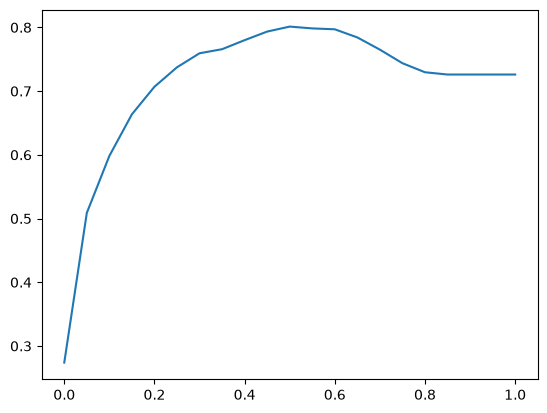

In [13]:
plt.plot(thresholds, scores)

In [14]:
sum(y_pred >= 1)

np.int64(0)

## Confusion Matrix

In [15]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
predict_positive = (y_pred >= 0.5)
predict_negative = (y_pred <0.5)

In [16]:
(predict_positive & actual_positive).sum()

np.int64(214)

In [17]:
(predict_negative & actual_negative).sum()

np.int64(915)

In [18]:
(predict_positive&actual_negative).sum()


np.int64(108)

In [19]:
(predict_negative&actual_positive).sum()


np.int64(172)

In [20]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive&actual_negative).sum()
fn = (predict_negative&actual_positive).sum()


In [21]:
confusion_matrix = np.array([
    [tn,fp],
    [fn,tp]
])
confusion_matrix

array([[915, 108],
       [172, 214]])

In [22]:
(confusion_matrix / confusion_matrix.sum()).round(3)

array([[0.649, 0.077],
       [0.122, 0.152]])

## Precision and recall

In [23]:
## Precision tells us the fraction of positive predictions that are correct. 
##It looks only at the customers we predicted to churn - the positive column of the confusion table

In [24]:
p = tp / (tp+fp)
p

np.float64(0.6645962732919255)

In [25]:
## Recall measures the fraction of actual positive instances that we identified correctly
## It looks at the customers who really churned, the positive row foo the confusion table


In [26]:
r = tp / (tp+fn)
r

np.float64(0.5544041450777202)

## Roc Curve

In [27]:
## False positive rate is false positive / all negatives or FP / FP+TN
## True positive rate is true positive / TP+FN
## note, true positive rate = recall = sensitivity 

tpr = tp / (tp + fn) 
fpr = fp / (fp+tn)


In [28]:
tpr, fpr

(np.float64(0.5544041450777202), np.float64(0.10557184750733138))

In [29]:
thresh = np.linspace(0, 1, 101)
scores = []

for t in thresh:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, fn, tn))

cols = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=cols)
df_scores

,threshold,tp,fp,fn,tn
0,0.00,386,1023,0,0
1,0.01,385,903,1,120
2,0.02,384,812,2,211
3,0.03,382,753,4,270
4,0.04,380,708,6,315
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [30]:
df_scores['tpr'] = df_scores['tp'] / (df_scores['tp']+df_scores['fn'])
df_scores['fpr'] = df_scores['fp'] / (df_scores['fp']+df_scores['tn'])

In [31]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,367,547,19,476,0.950777,0.534702
20,0.2,334,361,52,662,0.865285,0.352884
30,0.3,291,244,95,779,0.753886,0.238514
40,0.4,253,177,133,846,0.655440,0.173021
50,0.5,214,108,172,915,0.554404,0.105572
60,0.6,153,53,233,970,0.396373,0.051808
70,0.7,69,14,317,1009,0.178756,0.013685
80,0.8,5,0,381,1023,0.012953,0.000000
90,0.9,0,0,386,1023,0.000000,0.000000


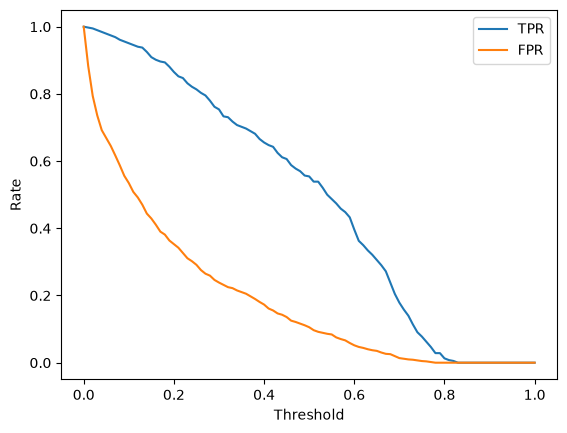

In [32]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

## random model

In [33]:
y_rand = np.random.uniform(0,1, size=len(y_val))
y_rand


array([0.58122036, 0.18358748, 0.40679785, ..., 0.40129111, 0.72949921,
       0.92792509], shape=(1409,))

In [34]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.48190205819730303)

In [35]:
def tpr_fpr_dataframe(y_val, y_pred):
    thresh = np.linspace(0, 1, 101)
    scores = []
    
    for t in thresh:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
    
        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
        scores.append((t, tp, fp, fn, tn))
    
    cols = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=cols)
    df_scores['tpr'] = df_scores['tp'] / (df_scores['tp']+df_scores['fn'])
    df_scores['fpr'] = df_scores['fp'] / (df_scores['fp']+df_scores['tn'])

    return df_scores
        

In [36]:
df_random = tpr_fpr_dataframe(y_val, y_rand)


In [37]:
df_random[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,351,934,35,89,0.909326,0.913001
20,0.2,302,842,84,181,0.782383,0.823069
30,0.3,267,744,119,279,0.691710,0.727273
40,0.4,229,643,157,380,0.593264,0.628543
50,0.5,185,529,201,494,0.479275,0.517107
60,0.6,150,422,236,601,0.388601,0.412512
70,0.7,110,318,276,705,0.284974,0.310850
80,0.8,69,205,317,818,0.178756,0.200391
90,0.9,33,98,353,925,0.085492,0.095797


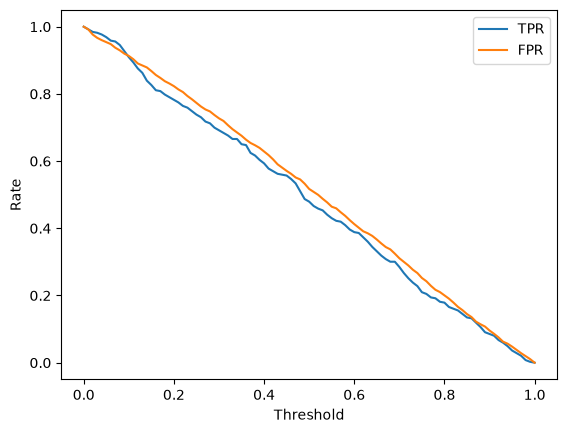

In [38]:
plt.plot(df_random.threshold, df_random.tpr, label='TPR')
plt.plot(df_random.threshold, df_random.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

### Ideal model

In [39]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [40]:
y_ideal = np.repeat([0,1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [41]:
y_ideal_pred = np.linspace(0,1, len(y_val))

In [42]:
((y_ideal_pred>= 0.726) == y_ideal).mean()

np.float64(1.0)

In [43]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]


,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


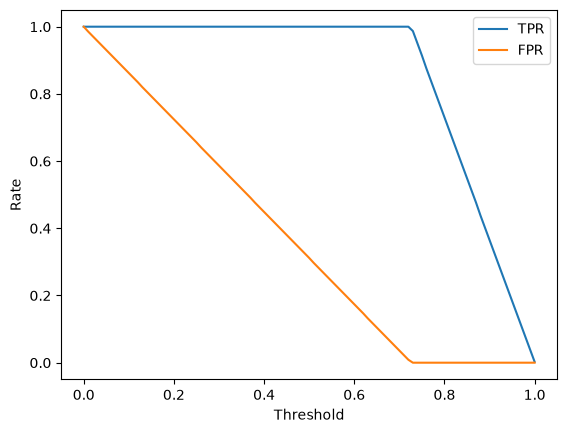

In [44]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

## Putting everything together

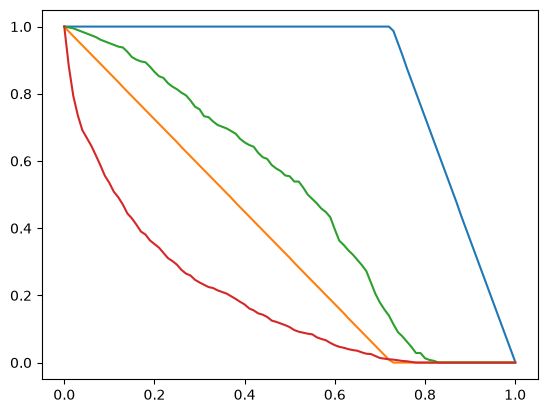

In [45]:
#plt.plot(df_random.threshold, df_random.tpr, label='TPR')
#plt.plot(df_random.threshold, df_random.fpr, label='FPR')

plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')

plt.plot(df_scores.threshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR')

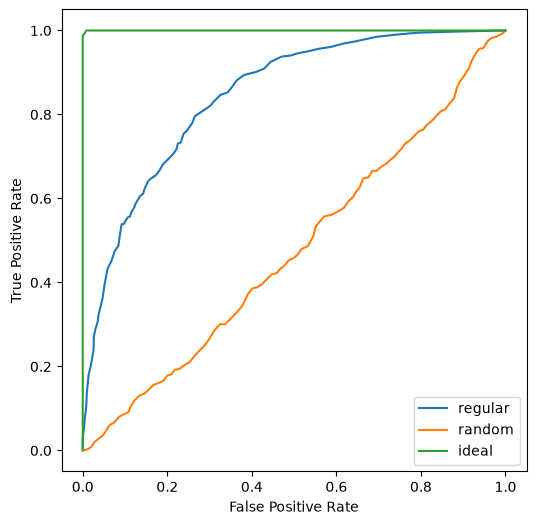

In [46]:
plt.figure(figsize=(6,6))
plt.plot(df_scores.fpr, df_scores.tpr, label='regular')
plt.plot(df_random.fpr, df_random.tpr, label='random')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Text(0, 0.5, 'false positive rate')

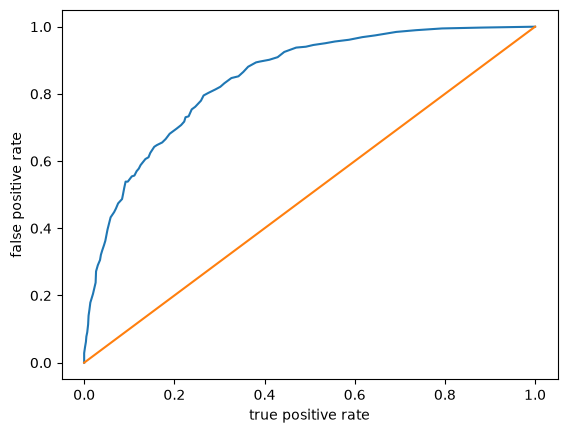

In [48]:
plt.plot(df_scores.fpr, df_scores.tpr)
plt.plot([0,1], [0,1])
plt.xlabel('true positive rate')
plt.ylabel('false positive rate')

In [52]:
## use sklearn
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

Text(0, 0.5, 'false positive rate')

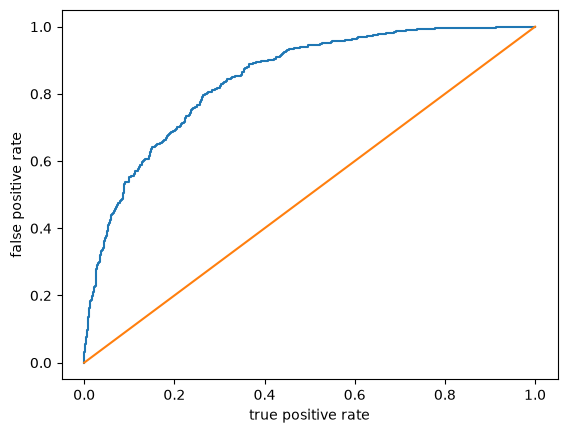

In [53]:
plt.plot(fpr,tpr)
plt.plot([0,1], [0,1])
plt.xlabel('true positive rate')
plt.ylabel('false positive rate')

## area under curve

In [54]:
## AUC is used to compare different models across all thresholds, rather than threshold tuning itself
from sklearn.metrics import auc

In [55]:
auc(fpr, tpr)

0.8445038720820102

In [56]:
   ## AUC is the probability that a randomly selected positive example has a greater score than a randomly selected negative example

In [57]:
neg = y_pred[y_val==0]
pos = y_pred[y_val==1]

In [60]:
import random

In [64]:
pos_ind = random.randint(0,len(pos)-1)
neg_ind = random.randint(0,len(neg)-1)

In [73]:
n = 100000
success = 0

for i in range (n):
    pos_ind = random.randint(0,len(pos)-1)
    neg_ind = random.randint(0,len(neg)-1)

    if pos[pos_ind] > neg[neg_ind]:
        success = success+1
success / n



0.84534

## Cross Validation

In [105]:
from sklearn.metrics import roc_auc_score
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient = 'records')

    dv = DictVectorizer(sparse = False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    return dv, model

In [106]:
dv, model = train(df_train, y_train)

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [107]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient = 'records')

    X=dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred

In [108]:
y_pred = predict(df_val, dv, model)

In [109]:
from sklearn.model_selection import KFold

In [110]:
kfold = KFold(n_splits = 10, shuffle = True, random_state = 1)

In [111]:
train_idx, val_idx = next(kfold.split(df_full_train))

In [112]:
df_train = df_full_train.reset_index().iloc[train_idx].copy()
df_val = df_full_train.reset_index().iloc[val_idx].copy()

In [113]:
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.reset_index().iloc[train_idx].copy()
    df_val = df_full_train.reset_index().iloc[val_idx].copy()
    
    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train,y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

In [114]:
scores

[0.8480670451473371,
 0.841042698019802,
 0.8557048652060528,
 0.8342276355855487,
 0.8265973945409429,
 0.8373459873459873,
 0.8445294692282644,
 0.8186195445920303,
 0.8452793834296726,
 0.863752478908272]

In [120]:
def train(df_train, y_train, C = 1.0):
    dicts = df_train[categorical + numerical].to_dict(orient = 'records')

    dv = DictVectorizer(sparse = False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter = 10000)
    model.fit(X_train, y_train)

    return dv, model

In [121]:
dv, model = train(df_train, y_train, C = 0.0001)

In [124]:
n_splits = 5
for C in [0, 0.001, 0.01, 0.1, 0.5, 1, 5, 10]:
    scores = []
    kfold = KFold(n_splits = n_splits, shuffle = True, random_state = 1)
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.reset_index().iloc[train_idx].copy()
        df_val = df_full_train.reset_index().iloc[val_idx].copy()
        
        y_train = df_train.churn.values
        y_val = df_val.churn.values
    
        dv, model = train(df_train,y_train)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    print(C, np.mean(scores), np.std(scores))

0 0.8418460182682992 0.0069071206359891
0.001 0.8418460182682992 0.0069071206359891
0.01 0.8418460182682992 0.0069071206359891
0.1 0.8418460182682992 0.0069071206359891
0.5 0.8418460182682992 0.0069071206359891
1 0.8418460182682992 0.0069071206359891
5 0.8418460182682992 0.0069071206359891
10 0.8418460182682992 0.0069071206359891


In [125]:
dv, model = train(df_full_train, df_full_train.churn.values, C = 1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)

In [126]:
auc

0.8584032088573997